<a href="https://colab.research.google.com/github/LetheeshBalaji/24ADI003-24BAD063/blob/main/income_random_forest_csvipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#24BAD063
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("income_random_forest.csv")

In [6]:
df.head()

,Age,EducationYears,HoursPerWeek,Experience,Income
0,37,12,44,12,0
1,46,19,58,33,1
2,53,10,54,24,0
3,46,11,22,6,0
4,36,17,56,3,1


**Data Preprocessing**


In [7]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             120 non-null    int64
 1   EducationYears  120 non-null    int64
 2   HoursPerWeek    120 non-null    int64
 3   Experience      120 non-null    int64
 4   Income          120 non-null    int64
dtypes: int64(5)
memory usage: 4.8 KB


In [8]:
df.isnull().sum()

,0
Age,0
EducationYears,0
HoursPerWeek,0
Experience,0
Income,0


In [9]:
df["Income"].value_counts()

,count
Income,
0,80
1,40


In [10]:


X = df.drop("Income", axis=1)
y = df["Income"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Train Random Forest with Different Number of Trees**

In [11]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
base_acc = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", base_acc)

tree_range = [10, 50, 100, 150, 200]
accuracies = []

for n in tree_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

Random Forest Accuracy: 1.0


**Accuracy vs Number of Trees Graph**

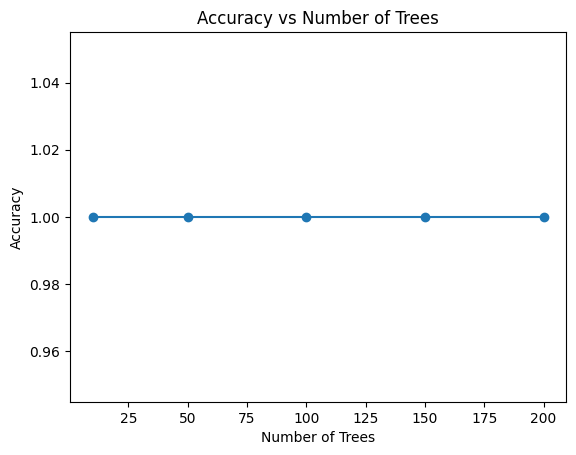

In [12]:
plt.figure()
plt.plot(tree_range, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()


**Feature Importance**

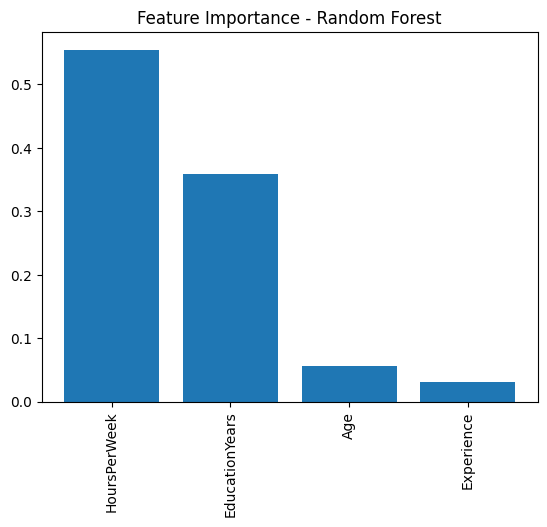

In [13]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importance - Random Forest")
plt.show()